In [1]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from mpl_toolkits.axes_grid1 import make_axes_locatable
from astropy.io import fits
from astropy.convolution import convolve
from astropy.modeling.models import Sersic2D
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
import astropy.units as u
from astropy.constants import c
from reproject import reproject_interp
from scipy.optimize import minimize, least_squares
from scipy.signal import fftconvolve, convolve2d
import dynesty
import dynesty.pool as dypool
from dynesty import plotting as dyplot
import dynesty.utils as dyutil
import pickle
import corner
from cmcrameri import cm
from multiprocessing import Pool
import importlib
import warnings
warnings.simplefilter('ignore', DeprecationWarning)
%matplotlib inline
# seed the random number generator
rstate = np.random.default_rng(111)

from glint.beam import cleanbeam_from_header
import glint.lensing as ls
from glint.context import ImageContext
from glint.forward import forward_model_3D_image
from glint.inference import run_emcee
from glint.plotstyle import set_my_plot_style
from params_kinematics import param_names, param_table

In [2]:
set_my_plot_style()

In [3]:
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

## Data

Set OBSGEO-B to   -23.022886 from OBSGEO-[XYZ].
Set OBSGEO-H to     5053.796 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


hst peak: 8.0, 17.0 pix, corresponding to 0.160, 0.340 arcsec from the center
hst centroid: 4.7, 3.5 pix, corresponding to 0.093, 0.070 arcsec from the center
hst gaussian fit: 10.8, 14.5 pix, corresponding to 0.217, 0.290 arcsec from the center
Number of pixels in the mask: 26404
Number of channels: 23
Number of pixels in image plane: 201 x 201
Pixel scale in image plane: 0.02 arcsec/pixel


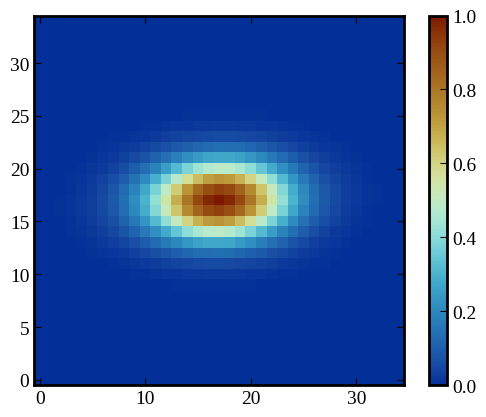

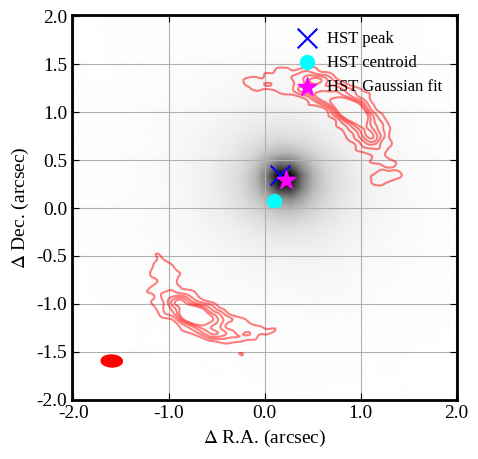

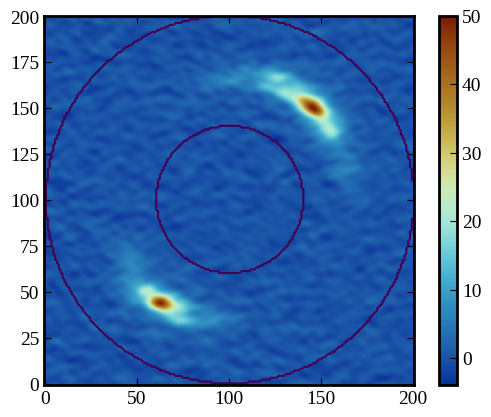

In [4]:
# image data
data_dir = Path("./data").resolve()
data_dir.exists()

obsfits   = str(data_dir / "B6_concat_CII_dv25km_rob-0.5_clean.image.pbcor.cutout.-250+300km.fits")
noisefits = str(data_dir / "B6_concat_CII_dv25km_rob-0.5_clean.noise.pbcor.cutout.-250+300km.fits")

obsdata, obsheader = fits.getdata(obsfits, header=True)
noisedata = fits.getdata(noisefits)
noisedata_inv = 1/noisedata
BMAJ, BMIN, BPA, CDELT = obsheader['BMAJ'], obsheader['BMIN'], obsheader['BPA'], obsheader['CDELT2']

beam = cleanbeam_from_header(35, obsheader)
plt.imshow(beam, origin="lower", cmap=cm.roma_r)
plt.colorbar()


#### Continuum data for overlay ####
contfits   = str(data_dir / "B6_concat_cont_rob-0.5_clean.image.pbcor.cutout.fits")
contnoisefits = str(data_dir / "B6_concat_cont_rob-0.5_clean.noise.pbcor.cutout.fits")

contdata, contheader = fits.getdata(contfits, header=True)
contnoisedata = fits.getdata(contnoisefits)
####

# あとは同じ
hst_fits = str(data_dir / "hst_skycell-p1356x14y05_wfc3_ir_f125w_coarse-all_drz.fits")
hst_data, hst_header = fits.getdata(hst_fits, header=True)
hst_wcs = WCS(hst_header)

# reproject to ALMA
hst_on_alma, footprint = reproject_interp((hst_data, hst_wcs), WCS(contheader, naxis=2), shape_out=contdata.shape)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(hst_on_alma, origin='lower', cmap='gray_r')
ax.contour(contdata/contnoisedata, levels=[4,8,12,16,20], colors='red', alpha=0.5)

# 画像の中心
ny, nx = contdata.shape
x0 = (nx - 1) / 2
y0 = (ny - 1) / 2
pixscale_as = abs(obsheader['CDELT2'] * 3600) # arcsec/pix
def format_func_x(x_pix, _):
    return f"{(x_pix - x0) * pixscale_as:.1f}"
def format_func_y(y_pix, _):
    return f"{(y_pix - y0) * pixscale_as:.1f}"
from matplotlib.ticker import FuncFormatter
ax.xaxis.set_major_formatter(FuncFormatter(format_func_x))
ax.yaxis.set_major_formatter(FuncFormatter(format_func_y))

# psfサイズをimage planeの左下に楕円として表示
xy_beam = (0.10*nx, 0.10*ny)
ellipse = Ellipse(xy=xy_beam, width=BMAJ/CDELT, height=BMIN/CDELT, angle=BPA+90, edgecolor='red', facecolor='red', lw=1.5)
ax.add_patch(ellipse)
ax.grid()

# HST peak
hst_peak = np.unravel_index(np.nanargmax(hst_on_alma), hst_on_alma.shape)
ax.scatter(hst_peak[1], hst_peak[0], marker='x', color='blue', s=200, label='HST peak')

# HST centroid
from photutils.centroids import centroid_com
y_com, x_com = centroid_com(hst_on_alma)
ax.scatter(x_com, y_com, marker='o', color='cyan', s=100, label='HST centroid')

# HST gaussian fit
def gauss2d(p, x, y):
    A, x0, y0, sx, sy, rho, c = p
    # 相関rho入り楕円ガウス：必要なければ rho=0 に固定
    X = (x - x0); Y = (y - y0)
    z = (X/sx)**2 + (Y/sy)**2 - 2*rho*X*Y/(sx*sy)
    return A*np.exp(-0.5/(1-rho**2) * z) + c
ny, nx = hst_on_alma.shape
yy, xx = np.indices((ny, nx))
p0 = [hst_on_alma.max(), x_com, y_com, 3.0, 3.0, 0.0, 0.0]
use = np.isfinite(hst_on_alma)
def resid(p): return (gauss2d(p, xx[use], yy[use]) - hst_on_alma[use])
res = least_squares(resid, p0, bounds=([0,0,0,0.5,0.5,-0.5,-np.inf],
                                       [np.inf,nx,ny,50,50,0.5,np.inf]))
A,x0_g,y0_g,sx,sy,rho,c = res.x
ax.scatter(x0_g, y0_g, marker='*', color='magenta', s=200, label='HST Gaussian fit')

ax.set_xlabel(r"$\Delta$ R.A. (arcsec)", fontsize=14)
ax.set_ylabel(r"$\Delta$ Dec. (arcsec)", fontsize=14)
ax.legend(fontsize=12)
print(f"hst peak: {hst_peak[1]-x0:.1f}, {hst_peak[0]-y0:.1f} pix, corresponding to {((hst_peak[1]-x0)*pixscale_as):.3f}, {((hst_peak[0]-y0)*pixscale_as):.3f} arcsec from the center")
print(f"hst centroid: {x_com-x0:.1f}, {y_com-y0:.1f} pix, corresponding to {((x_com-x0)*pixscale_as):.3f}, {((y_com-y0)*pixscale_as):.3f} arcsec from the center")
print(f"hst gaussian fit: {x0_g-x0:.1f}, {y0_g-y0:.1f} pix, corresponding to {((x0_g-x0)*pixscale_as):.3f}, {((y0_g-y0)*pixscale_as):.3f} arcsec from the center")

x0_l = (x0_g-x0)*pixscale_as
y0_l = (y0_g-y0)*pixscale_as


# mask definition
maskdata = np.zeros(contdata.shape).astype(bool)

# RMS基準にマスクを定義する場合
# thresh = 2
# maskdata[obsdata*noisedata_inv > thresh] = True

# 固定マスクを使う場合
# 円環マスク
r_inner = 0.8 # arcsec
r_outer = 2.0 # arcsec
y, x = np.indices(contdata.shape)
x_center = contdata.shape[1] / 2
y_center = contdata.shape[0] / 2
r = np.sqrt((x - x_center)**2 + (y - y_center)**2) * np.abs(CDELT) * 3600
maskdata[(r >= r_inner) & (r <= r_outer)] = True


Npix = np.nansum(maskdata)
print(f"Number of pixels in the mask: {Npix}")

# mask
# obsdata[maskdata==0] = np.nan
# noisedata_inv[maskdata==0] = np.nan

fig, ax = plt.subplots()
im = ax.imshow(contdata/contnoisedata, origin="lower", cmap=cm.roma_r)
ax.contour(maskdata)
fig.colorbar(im, ax=ax)



# source plane grid
ny_src, nx_src = 200, 200
pixsize_src = 0.005 # arcsec
x0_src, y0_src = 0.0, 0.0
xx_src, yy_src = ls.make_grid_arcsec(nx=nx_src, ny=ny_src, pixscale_arcsec=pixsize_src, x0_arcsec=x0_src, y0_arcsec=y0_src)

# image plane grid
nchan, ny_img, nx_img = obsdata.shape
pixsize_img = (np.abs(obsheader['CDELT2'])*3600).round(5)
print(f"Number of channels: {nchan}")
print(f"Number of pixels in image plane: {nx_img} x {ny_img}")
print(f"Pixel scale in image plane: {pixsize_img} arcsec/pixel")
x0_img, y0_img = 0.0, 0.0
xx_img, yy_img = ls.make_grid_arcsec(nx=nx_img, ny=ny_img, pixscale_arcsec=pixsize_img, x0_arcsec=x0_img, y0_arcsec=y0_img)

radius = np.arange(0, 0.8+1e-6, 0.01) # 0含める

# spec_res_sgm_kms = 50 / (2 * np.sqrt(2 * np.log(2)))  # 50 km/s channel width -> sigma
spec_res_sgm_kms = 25 / (2 * np.sqrt(2 * np.log(2)))  # 25 km/s channel width -> sigma


In [5]:
from astropy.constants import c
# 周波数方向の情報

# model作成時は速度で指定
vchan_kms = np.arange(-250, 301, 25)

# [CII]158を想定
REST_FREQ_CII = 1900.5369 * u.GHz
z = 6.024
OBS_FREQ_CII = REST_FREQ_CII / (1 + z)

# Transform velocity channels to frequency channels
# V/c = -dnu/f --> dnu = - (V/c) * f --> nu = f + dnu = f * (1 - V/c)
fchan_GHz = (OBS_FREQ_CII * (1 - vchan_kms / c.to(u.km / u.s).value)).to(u.GHz).value
print(fchan_GHz)

f0 = fchan_GHz[0]
df = np.mean(np.diff(fchan_GHz))
print(f"f0: {f0} GHz, df: {df} GHz, RESTFRQ: {OBS_FREQ_CII.to(u.GHz).value} GHz")

[270.80321429 270.78065055 270.75808681 270.73552307 270.71295933
 270.69039559 270.66783184 270.6452681  270.62270436 270.60014062
 270.57757688 270.55501314 270.5324494  270.50988566 270.48732191
 270.46475817 270.44219443 270.41963069 270.39706695 270.37450321
 270.35193947 270.32937573 270.30681199]
f0: 270.80321429080266 GHz, df: -0.022563741153158453 GHz, RESTFRQ: 270.5775768792711 GHz


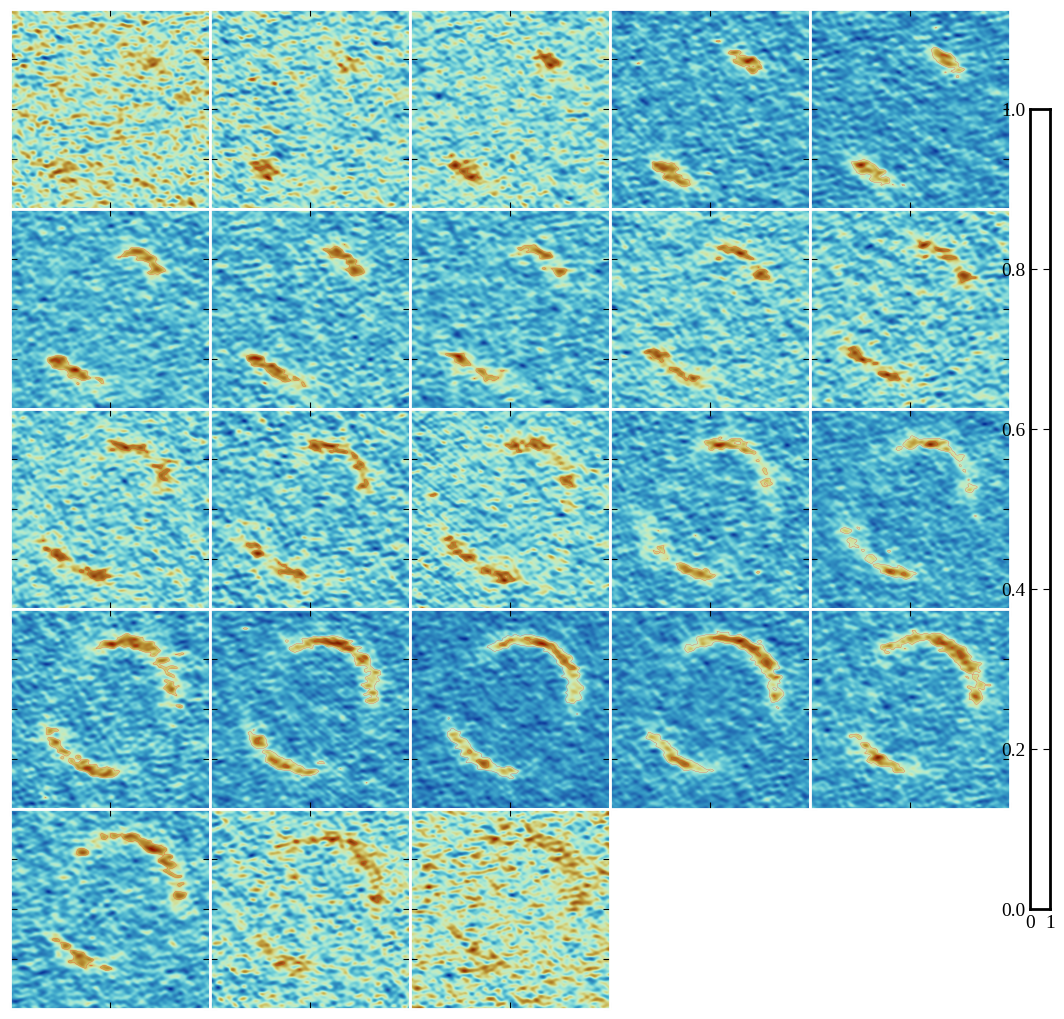

In [6]:
# plot channel maps
n_cols = 5
n_chan = obsdata.shape[0]
n_rows = int(np.ceil(n_chan / n_cols))

start = 0

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(2*n_cols, 2*n_rows))
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.0, hspace=0.0)
for i in range(n_rows * n_cols):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row, col]
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.spines['bottom'].set_color("white")
    ax.spines['top'].set_color("white")
    ax.spines['right'].set_color("white")
    ax.spines['left'].set_color("white")
    if i < n_chan:
        ax.imshow(obsdata[start+i], cmap=cm.roma_r, origin="lower")#, vmin=-2*rms, vmax=10*rms)
        ax.contour(obsdata[start+i]/noisedata[start+i], levels=[4, 8, 12, 16, 32], colors='red', alpha=0.7, linewidths=0.2)
        
        # ax.annotate(f"{int(vel_start+dv*i)}km/s", xy=(0.25, 0.87), xytext=(0, 0), color='white', xycoords='axes fraction', textcoords='offset points',weight='bold', ha='center', va='baseline', fontsize=25)
        # ellipse = Ellipse(xy=(0,0), width=BMAJ, height=BMIN, angle=BPA+90.,edgecolor='none', fc='white', lw=0.5)  # must be define any time
        # ax.add_patch(ellipse)
    
    # if i==0:
    #     size = 1/pix
    #     fontprops = fm.FontProperties(size=40)
    #     scalebar = AnchoredSizeBar(ax.transData,
    #                             size, r'1$^{\prime\prime}$', 'lower right',
    #                             pad=0.3,
    #                             sep=5,
    #                             color='white',
    #                             frameon=False,
    #                             size_vertical=2,
    #                             fontproperties=fontprops)
    #     ax.add_artist(scalebar)
    
    if i >= n_chan:
        ax.axis('off')

# 全体のカラーバー
cbar_ax = fig.add_axes([1.02, 0.1, 0.02, 0.8])  # [left, bottom, width, height]
# norm = plt.Normalize(vmin=-2*rms, vmax=10*rms)
# cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cm.roma_r), cax=cbar_ax)

## Common setting

In [7]:
ctx = ImageContext(
    xx_img = xx_img,
    yy_img = yy_img,
    xx_src = xx_src,
    yy_src = yy_src,
    pixsize_img = pixsize_img,
    pixsize_src = pixsize_src,
    x0_src = x0_src,
    y0_src = y0_src,
    x0_l = x0_l,
    y0_l = y0_l,
    vchan_kms = vchan_kms,
    spec_res_sgm_kms = spec_res_sgm_kms,
    radius_arcsec = radius,
    beam = beam
)

In [8]:
x0 = param_table[:,0]
lb = param_table[:,1]
ub = param_table[:,2]
ndim = len(lb)

## fitting

In [10]:
# from mom-0 fit

savename = f"./mcmc_chain_CII_mom0_image.npz"
npzfile = np.load(savename, allow_pickle=True)

chain = npzfile["chain"]              # shape: (nsteps, nwalkers, ndim)
logprob = npzfile["logprob"]          # shape: (nsteps, nwalkers)
param_names_mom0 = list(npzfile["param_names"])

# 最も logprob が大きい点を best-fit とする
idx = np.unravel_index(np.argmax(logprob), logprob.shape)
best_theta = chain[idx[0], idx[1], :]

for name, best in zip(param_names_mom0, best_theta):
    print(f"{name:12s}  best={best:10.4f}")

ellip = best_theta[3]
axis_ratio = 1 - ellip
print(f"Best-fit axis ratio: {axis_ratio:.3f}")
inc_deg_from_mom0_fit = np.degrees(np.arccos(axis_ratio))
print(f"Best-fit inclination: {inc_deg_from_mom0_fit:.2f} deg")

x_s           best=    0.0348
y_s           best=    0.0291
F_0           best=    9.4547
ellip         best=    0.1517
pa_deg        best=  100.4099
r_eff         best=    0.2009
n             best=    0.5000
b             best=    1.2845
q_l           best=    0.9558
pa_l          best=    2.3784
log_gamma     best=   -1.2749
pa_gamma      best=    1.0912
Best-fit axis ratio: 0.848
Best-fit inclination: 31.97 deg


In [11]:
# Fix inc_deg to the best-fit value from the moment-0 fit

x0[3] = inc_deg_from_mom0_fit
lb[3] = inc_deg_from_mom0_fit-1e-5
ub[3] = inc_deg_from_mom0_fit+1e-5

In [12]:
from glint.inference import run_least_squares

dof = np.sum(maskdata) * obsdata.shape[0]  # number of pixels in the mask * number of channels
dof_inv = 1/dof

# def residual(theta):
#     model = forward_model_3D_image(theta, ctx)[2]
#     diff = (obsdata - model) * noisedata_inv
#     chi2 = np.sum(diff[:, maskdata]**2) * dof_inv
#     return chi2

mask_flat = maskdata.ravel()
def residual_vec(theta):
    model = forward_model_3D_image(theta, ctx)[2]          # (nchan, ny, nx)
    r = (obsdata - model) * noisedata_inv                  # 同shape
    r = r.reshape(r.shape[0], -1)[:, mask_flat]            # (nchan, Nmask)
    return r.ravel()                                       # (nchan*Nmask,)


result = run_least_squares(residual_vec, x0, lb, ub)

   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.0254e+06                                    1.20e+07    
       1              2         6.1776e+05      1.41e+06       7.17e+00       2.08e+06    
       2              3         4.1582e+05      2.02e+05       8.84e+00       3.88e+05    
       3              4         3.7467e+05      4.11e+04       1.92e+01       3.39e+05    
       4              5         3.6597e+05      8.69e+03       1.22e+01       2.66e+05    
       5              6         3.6038e+05      5.59e+03       4.84e+01       1.06e+05    
       6              7         3.5562e+05      4.76e+03       4.83e+00       1.29e+04    
       7              8         3.5336e+05      2.26e+03       7.46e+00       9.78e+03    
       8              9         3.5217e+05      1.19e+03       4.34e+00       6.01e+03    
       9             10         3.5156e+05      6.02e+02       2.37e+00       1.07e+04    

In [13]:
best_fit = result.x

print("Best-fit parameters:")
for name, val in zip(param_names, best_fit):
    print(f"{name}: {val:.4f}")

Best-fit parameters:
x_s: 0.0287
y_s: 0.0250
F_0: 1.5391
inc_deg: 31.9748
pa_deg: 56.6309
r_scale: 0.1286
v_c: 344.5717
r_turn: 0.0100
gamma_curve: 1.5000
sigma_0: 92.7485
r_sigma: 0.7995
vsys_kms: 17.3201
b: 1.2707
q_l: 0.9151
pa_l: 0.0000
log_gamma: -1.2048
pa_gamma: 0.8689


Saved to ./figure/rotation_curve_fit_G09_lens_fix.pdf


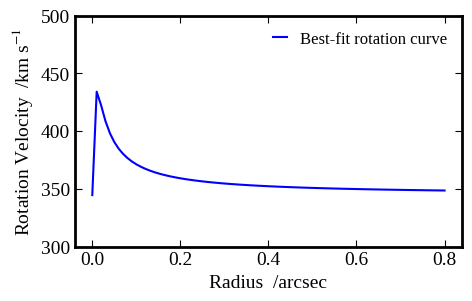

In [14]:
# rotation curve
from glint.source import Vrot_Courteau1997

radius_rc = np.arange(0, 0.8+1e-6, 0.01) # 0含める
vrot_bestfit = Vrot_Courteau1997(r=radius_rc, v_c=best_fit[6], r_turn=best_fit[7], gamma=best_fit[8], beta=1.0)
 

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(radius_rc, vrot_bestfit, color='blue', label='Best-fit rotation curve')
ax.set_xlabel('Radius  /arcsec', fontsize=14)
ax.set_ylabel(r'Rotation Velocity  /km s$^{-1}$', fontsize=14)
ax.legend(fontsize=12)
ax.set_ylim(300, 500)
fig.savefig("./figure/rotation_curve_fit_G09_lens_fix.pdf", dpi=200, bbox_inches="tight")
print("Saved to ./figure/rotation_curve_fit_G09_lens_fix.pdf")
plt.show()

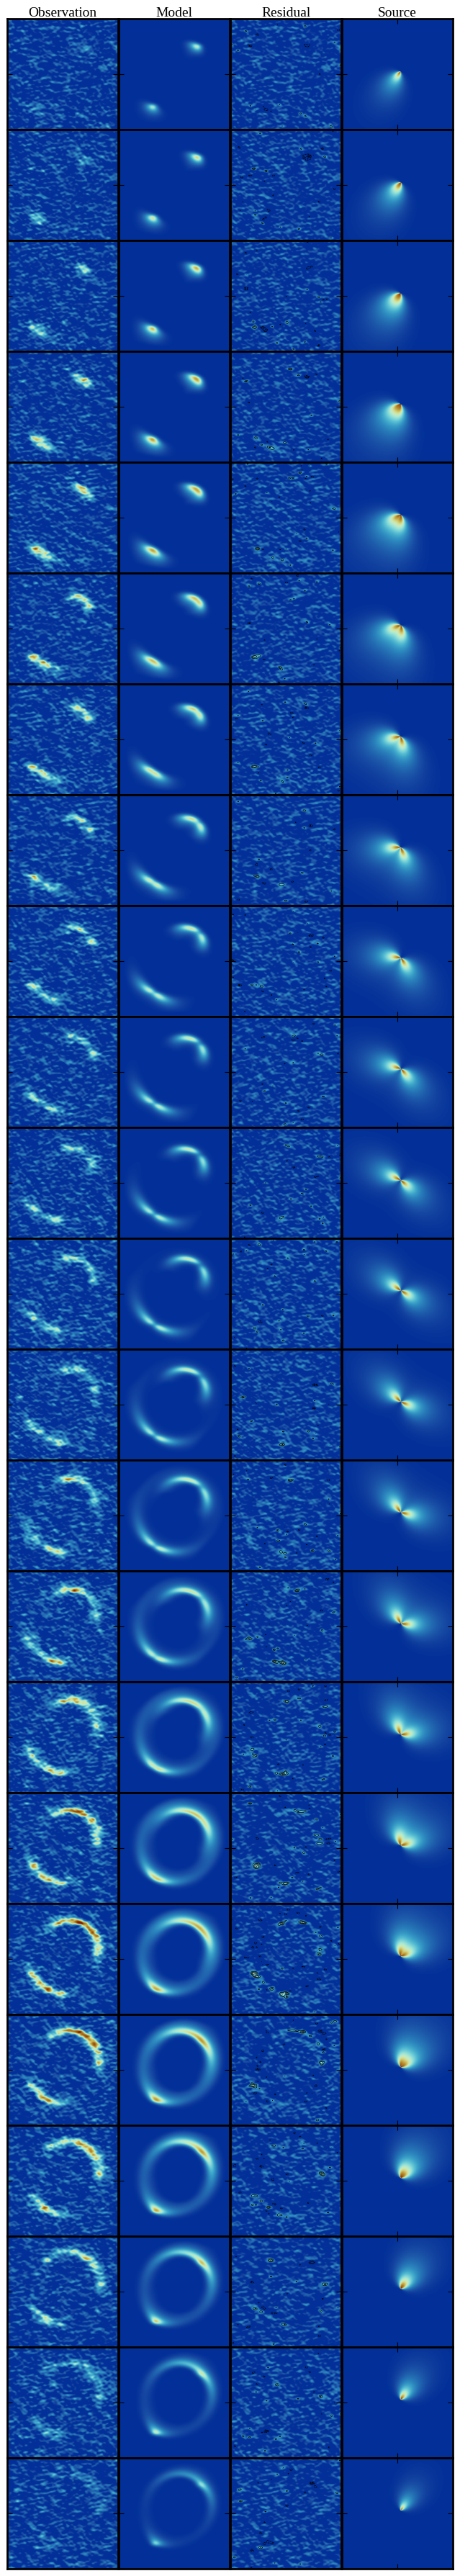

In [15]:
# model with best-fit parameters
best_source, best_lensed_cube, best_lensed_cube_conv = forward_model_3D_image(best_fit, ctx)

# Plot cube for each channel
# Some settings for plotting
vmax = np.nanmax(obsdata) * 0.9
width = 2
titles = ["Observation", "Model", "Residual", "Source"]


fig, axes = plt.subplots(nchan, ncols=4, figsize=(width*4, width*nchan))
fig.subplots_adjust(wspace=0., hspace=0.0)
for i in range(nchan):
    im0 = axes[i, 0].imshow(obsdata[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
    # axes[i, 0].contour(obsdata[i]/noisedata[i], levels=[8,16,32], colors='black', linewidths=1.0)
    im1 = axes[i, 1].imshow(best_lensed_cube_conv[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
    im2 = axes[i, 2].imshow((obsdata[i] - best_lensed_cube_conv[i]), cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
    # im2 = axes[i, 2].imshow((obsdata[i] - best_lensed_cube_conv[i]) / noisedata[i], cmap=cm.roma_r, origin="lower", vmin=-3, vmax=3)
    axes[i, 2].contour((obsdata[i] - best_lensed_cube_conv[i]) / noisedata[i], levels=[-5,-4,-3,3,4,5], colors='black', linewidths=0.5)
    im3 = axes[i, 3].imshow(best_source[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=np.nanmax(best_source))

    if i==0:
        for j in range(4):
            axes[i, j].set_title(titles[j], fontsize=14, pad=-2)
    for j in range(4):
        # divider = make_axes_locatable(axes[i,j])
        # cax = divider.append_axes("right", size="5%", pad=0.)
        # fig.colorbar([im0, im1, im2, im3][j], cax=cax)
        axes[i, j].set_xticklabels([])
        axes[i, j].set_yticklabels([])

    
# fig.savefig("./figure/channel_maps_fit_G09_lens_fix.pdf", dpi=200, bbox_inches="tight")
# print("Saved to ./figure/channel_maps_fit_G09_lens_fix.pdf")
# plt.tight_layout()

In [16]:
from glint.inference import logprior_box


def loglike(theta):
    model = forward_model_3D_image(theta, ctx)[2]
    diff = (obsdata - model) * noisedata_inv
    chi2 = np.sum(diff[:, maskdata]**2)
    return -0.5 * chi2


def logprob(theta):
    lp = logprior_box(theta, lb, ub)
    if not np.isfinite(lp):
        return -np.inf
    ll = loglike(theta)
    # if not np.isfinite(ll):
    #     return -np.inf
    return lp + ll

In [ ]:
# x0 = best_fit # fitの初期値からスタート
chain, logprob, sampler = run_emcee(logprob_fn=logprob, x0=x0, lb=lb, ub=ub, nwalkers=4*len(lb), burnin=2000, production=10000, ncpu=24, init_frac=0.2, skip_initial_state_check=False)


savename = f"./mcmc_chain_G09_cube_image.npz"
np.savez(savename,
         chain=chain,
         logprob=logprob,
         param_names=param_names)

print(f"MCMC chain saved to {savename}.")

[init] min std over dims = 1.142e-01, median std = 1.739e-01
Running burn-in with 24 CPUs...


  1%|          | 18/2000 [00:06<13:10,  2.51it/s]

## Corner plot

Loaded chain:
 chain shape: (10000, 68, 17)
 logprob shape: (10000, 68)
 ndim: 17

Flattened chain shape: (680000, 17)


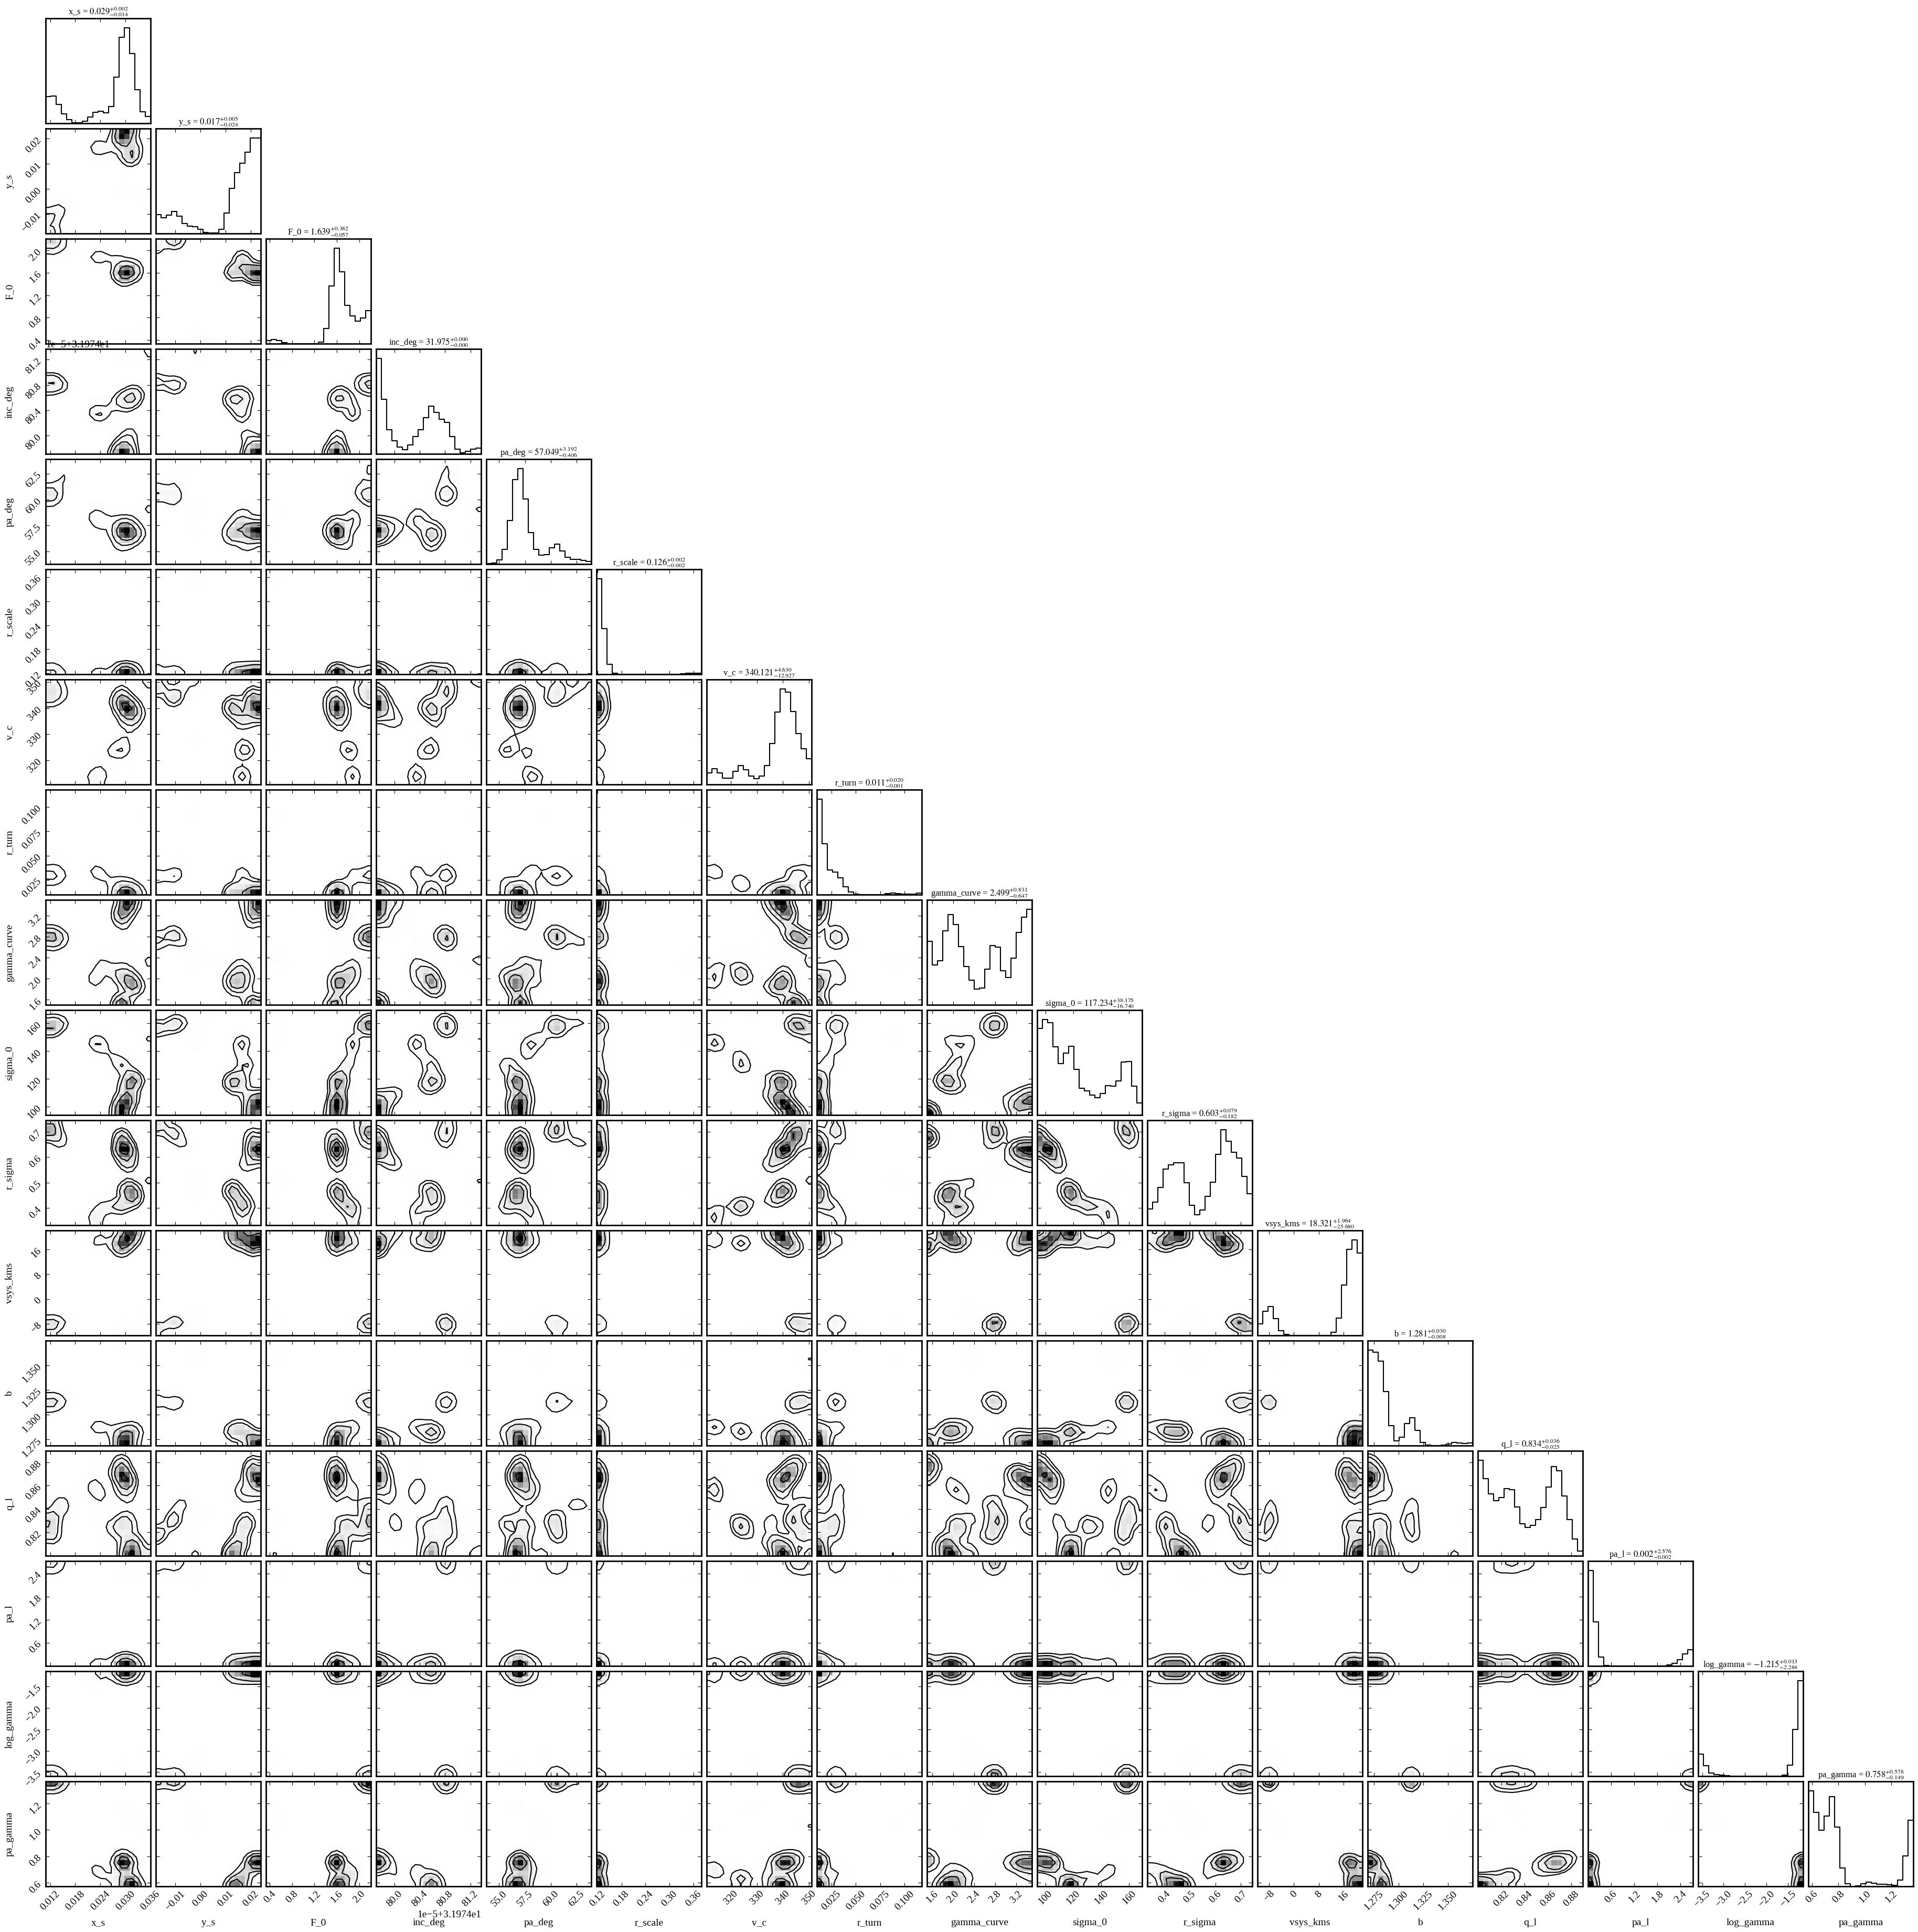


Saved corner plot: ./figure/corner_G09_lens_fix.pdf

Best-fit parameters
x_s           best=    0.0288
y_s           best=    0.0206
F_0           best=    1.5544
inc_deg       best=   31.9748
pa_deg        best=   57.0253
r_scale       best=    0.1282
v_c           best=  344.8898
r_turn        best=    0.0104
gamma_curve   best=    1.5740
sigma_0       best=   94.7799
r_sigma       best=    0.7157
vsys_kms      best=   15.5839
b             best=    1.2742
q_l           best=    0.8806
pa_l          best=    0.0023
log_gamma     best=   -1.2138
pa_gamma      best=    0.7797


In [9]:
from unicodedata import name

import numpy as np
import corner
import matplotlib.pyplot as plt

# ===============================
# Load saved chain
# ===============================

savename = f"./mcmc_chain_G09_cube_image.npz"
npzfile = np.load(savename, allow_pickle=True)

chain = npzfile["chain"]              # shape: (nsteps, nwalkers, ndim)
logprob = npzfile["logprob"]          # shape: (nsteps, nwalkers)
param_names = list(npzfile["param_names"])

print("Loaded chain:")
print(" chain shape:", chain.shape)
print(" logprob shape:", logprob.shape)
print(" ndim:", len(param_names))

# ===============================
# Flatten chain
# ===============================

nsteps, nwalkers, ndim = chain.shape
flat_chain = chain.reshape((-1, ndim))

print("\nFlattened chain shape:", flat_chain.shape)


# ===============================
# Corner plot
# ===============================

fig = corner.corner(
    flat_chain,
    labels=param_names,
    show_titles=True,
    smooth=1.0,
    smooth1d=1.0,
    plot_density=True,
    plot_datapoints=False,
    title_fmt=".3f",
    title_kwargs={"fontsize": 12},
)

fig.savefig("./figure/corner_G09_lens_fix.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("\nSaved corner plot: ./figure/corner_G09_lens_fix.pdf")

# ===============================
# 最尤推定値
# ===============================
# 最も logprob が大きい点を best-fit とする
idx = np.unravel_index(np.argmax(logprob), logprob.shape)
best_theta = chain[idx[0], idx[1], :]

print("\n==============================")
print("Best-fit parameters")
print("==============================")

for name, best in zip(param_names, best_theta):
    print(f"{name:12s}  best={best:10.4f}")

In [12]:
### rotation curve with error band ###
# サンプルから rotation curve を計算
from tqdm import tqdm
from glint.source import Vrot_Courteau1997
n_samples = flat_chain.shape[0]
radius_rc = np.arange(0, 0.8+1e-6, 0.01) # 0含める

# 5個おきのサンプルだけ使う

idx = np.arange(0, n_samples, 2)

vrot_samples = []
sigma_samples = []
for i in tqdm(range(0, n_samples, 2)):
    params = flat_chain[i]
    v_c = params[6]
    r_turn = params[7]
    gamma_curve = params[8]
    sigma_0 = params[9]
    r_sigma = params[10]
    vrot_samples.append(Vrot_Courteau1997(r=radius_rc, v_c=v_c, r_turn=r_turn, gamma=gamma_curve, beta=1.0))
    sigma_samples.append(sigma_0 * np.exp(-radius_rc/r_sigma))

vrot_samples = np.array(vrot_samples)
vrot_median = np.nanmedian(vrot_samples, axis=0)
vrot_16 = np.nanpercentile(vrot_samples, 16, axis=0)
vrot_84 = np.nanpercentile(vrot_samples, 84, axis=0)   

sigma_samples = np.array(sigma_samples)
sigma_median = np.nanmedian(sigma_samples, axis=0)
sigma_16 = np.nanpercentile(sigma_samples, 16, axis=0)  
sigma_84 = np.nanpercentile(sigma_samples, 84, axis=0)

100%|██████████| 340000/340000 [00:05<00:00, 57801.10it/s]


Scale: 5.70 kpc/arcsec
Saved to ./figure/rotation_curve_G09_lens_fix.pdf


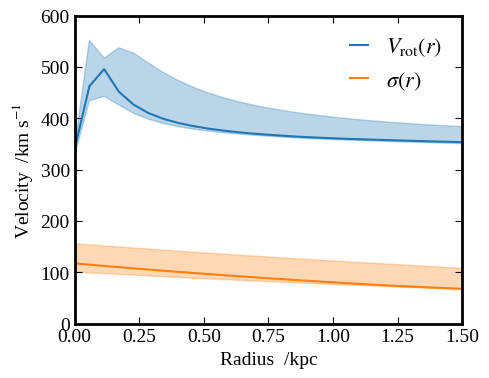

In [23]:
from astropy.cosmology import FlatLambdaCDM
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
z = 6.024
kpc_per_arcsec = cosmo.kpc_proper_per_arcmin(z).to(u.kpc / u.arcsec).value
print(f"Scale: {kpc_per_arcsec:.2f} kpc/arcsec")
radius_kpc = radius_rc * kpc_per_arcsec

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(radius_kpc, vrot_median, color='tab:blue', label=r'$V_{\mathrm{rot}}(r)$')
ax.fill_between(radius_kpc, vrot_16, vrot_84, color='tab:blue', alpha=0.3)
ax.plot(radius_kpc, sigma_median, color='tab:orange', label=r'$\sigma(r)$')
ax.fill_between(radius_kpc, sigma_16, sigma_84, color='tab:orange', alpha=0.3)
ax.set_xlabel('Radius  /kpc', fontsize=14)
ax.set_ylabel(r'Velocity  /km s$^{-1}$', fontsize=14)
ax.legend(fontsize=16)
ax.set_xlim(0, 1.5)
ax.set_ylim(0, 600)
fig.savefig("./figure/rotation_curve_G09_lens_fix.pdf", dpi=300, bbox_inches="tight")
print("Saved to ./figure/rotation_curve_G09_lens_fix.pdf")
plt.show()

## Compare models and observations

Saved to ./figure/channel_maps_G09_lens_fix.pdf


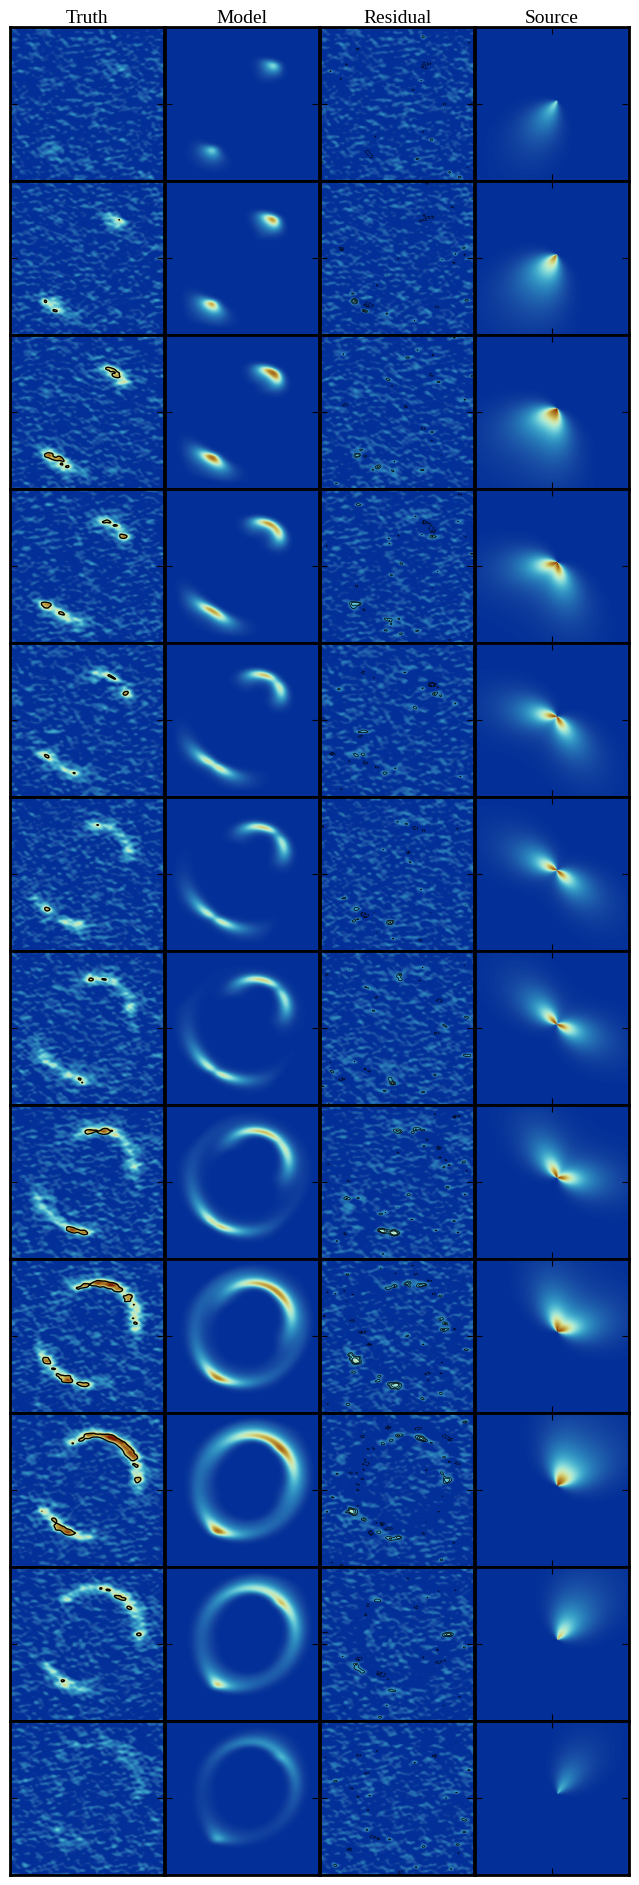

In [23]:
# model with best-fit parameters
best_source, best_lensed_cube, best_lensed_cube_conv = forward_model_3D_image(best_theta, ctx)

# Plot cube for each channel
# Some settings for plotting
vmax = np.nanmax(obsdata) * 0.9
width = 2
titles = ["Truth", "Model", "Residual", "Source"]


fig, axes = plt.subplots(nchan, ncols=4, figsize=(width*4, width*nchan))
fig.subplots_adjust(wspace=0., hspace=0.0)
for i in range(nchan):
    im0 = axes[i, 0].imshow(obsdata[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
    axes[i, 0].contour(obsdata[i]/noisedata[i], levels=[8,16,32], colors='black', linewidths=1.0)
    im1 = axes[i, 1].imshow(best_lensed_cube_conv[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
    # im2 = axes[i, 2].imshow((obsdata[i] - best_lensed_cube_conv[i]) / noisedata[i], cmap=cm.roma_r, origin="lower", vmin=-3, vmax=3)
    im2 = axes[i, 2].imshow((obsdata[i] - best_lensed_cube_conv[i]), cmap=cm.roma_r, origin="lower", vmin=0, vmax=vmax)
    axes[i, 2].contour((obsdata[i] - best_lensed_cube_conv[i]) / noisedata[i], levels=[-5,-4,-3,3,4,5], colors='black', linewidths=0.5)
    im3 = axes[i, 3].imshow(best_source[i], cmap=cm.roma_r, origin="lower", vmin=0, vmax=np.nanmax(best_source))

    if i==0:
        for j in range(4):
            axes[i, j].set_title(titles[j], fontsize=14, pad=-2)
    for j in range(4):
        # divider = make_axes_locatable(axes[i,j])
        # cax = divider.append_axes("right", size="5%", pad=0.)
        # fig.colorbar([im0, im1, im2, im3][j], cax=cax)
        axes[i, j].set_xticklabels([])
        axes[i, j].set_yticklabels([])

    
fig.savefig("./figure/channel_maps_G09_lens_fix.pdf", dpi=200, bbox_inches="tight")
print("Saved to ./figure/channel_maps_G09_lens_fix.pdf")
# plt.tight_layout()